In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [17]:
data_dir = Path("data")
atlas = "atlas/aal.nii"

masker = NiftiLabelsMasker(
    labels_img=atlas,
    standardize="zscore_sample"
)

connectome = ConnectivityMeasure(kind="correlation")

In [18]:
fc_matrices = []
fc_vectors = []
subject_ids = []

for f in sorted(data_dir.glob("*.nii")):
    roi_ts = masker.fit_transform(str(f))
    fc = connectome.fit_transform([roi_ts])[0]

    iu = np.triu_indices_from(fc, k=1)
    vec = fc[iu]

    fc_matrices.append(fc)
    fc_vectors.append(vec)
    subject_ids.append(f.stem)

X_matrix = np.stack(fc_matrices)   # (n_subjects, 116, 116)
X_vec = np.stack(fc_vectors)       # (n_subjects, 6670)

print("subjects:", subject_ids)
print("X_matrix shape:", X_matrix.shape)
print("X_vec shape:", X_vec.shape)

y = np.ones(len(subject_ids), dtype=int)
print("y shape:", y.shape)
print(y)

/tmp/ipykernel_1902/2421150205.py:7: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fc = connectome.fit_transform([roi_ts])[0]
/tmp/ipykernel_1902/2421150205.py:7: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, ple

subjects: ['sub-70001_task-rest_bold', 'sub-70004_task-rest_bold', 'sub-70007_task-rest_bold']
X_matrix shape: (3, 116, 116)
X_vec shape: (3, 6670)
y shape: (3,)
[1 1 1]


/tmp/ipykernel_1902/2421150205.py:7: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fc = connectome.fit_transform([roi_ts])[0]


In [19]:
np.save("X_matrix.npy", X_matrix)
np.save("X_vec.npy", X_vec)
np.save("y.npy", y)
np.save("subject_ids.npy", np.array(subject_ids))

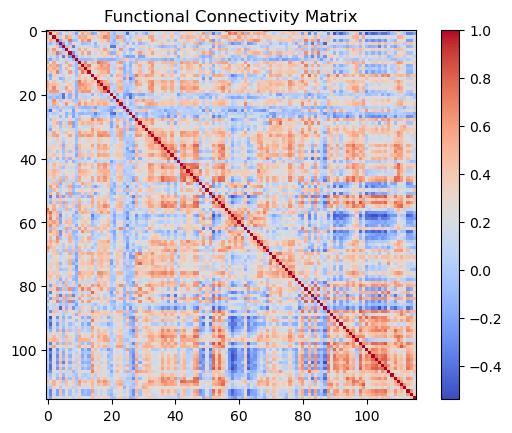

In [20]:
plt.imshow(fc_matrix, cmap="coolwarm")
plt.colorbar()
plt.title("Functional Connectivity Matrix")
plt.show()